🔍Final data check...
Data types:
price                float64
kilometrage          float64
seats                float64
transmission           int64
puissance_fiscale    float64
climatisation          int64
month                float64
car_age              float64
is_new                 int64
price_per_fiscal     float64
brand_encoded        float64
body_type_encoded    float64
model_encoded        float64
fuel_diesel            int64
fuel_electrique        int64
fuel_essence           int64
fuel_hybride           int64
dtype: object

Non-numeric columns: []
 Final clean dataset: (2226, 17)
Features shape: (2226, 16)
Target shape: (2226,)
 Data split completed!
Training set: (1780, 16)
Testing set: (446, 16)
 Feature scaling completed!

 TRAINING MODELS...

Training Linear Regression...
  MAE: 11,619 TND
  RMSE: 18,244 TND
  R²: 0.944

Training Ridge Regression...
  MAE: 11,619 TND
  RMSE: 18,244 TND
  R²: 0.944

Training Lasso Regression...
  MAE: 11,618 TND
  RMSE: 18,244 TND
  R²: 0

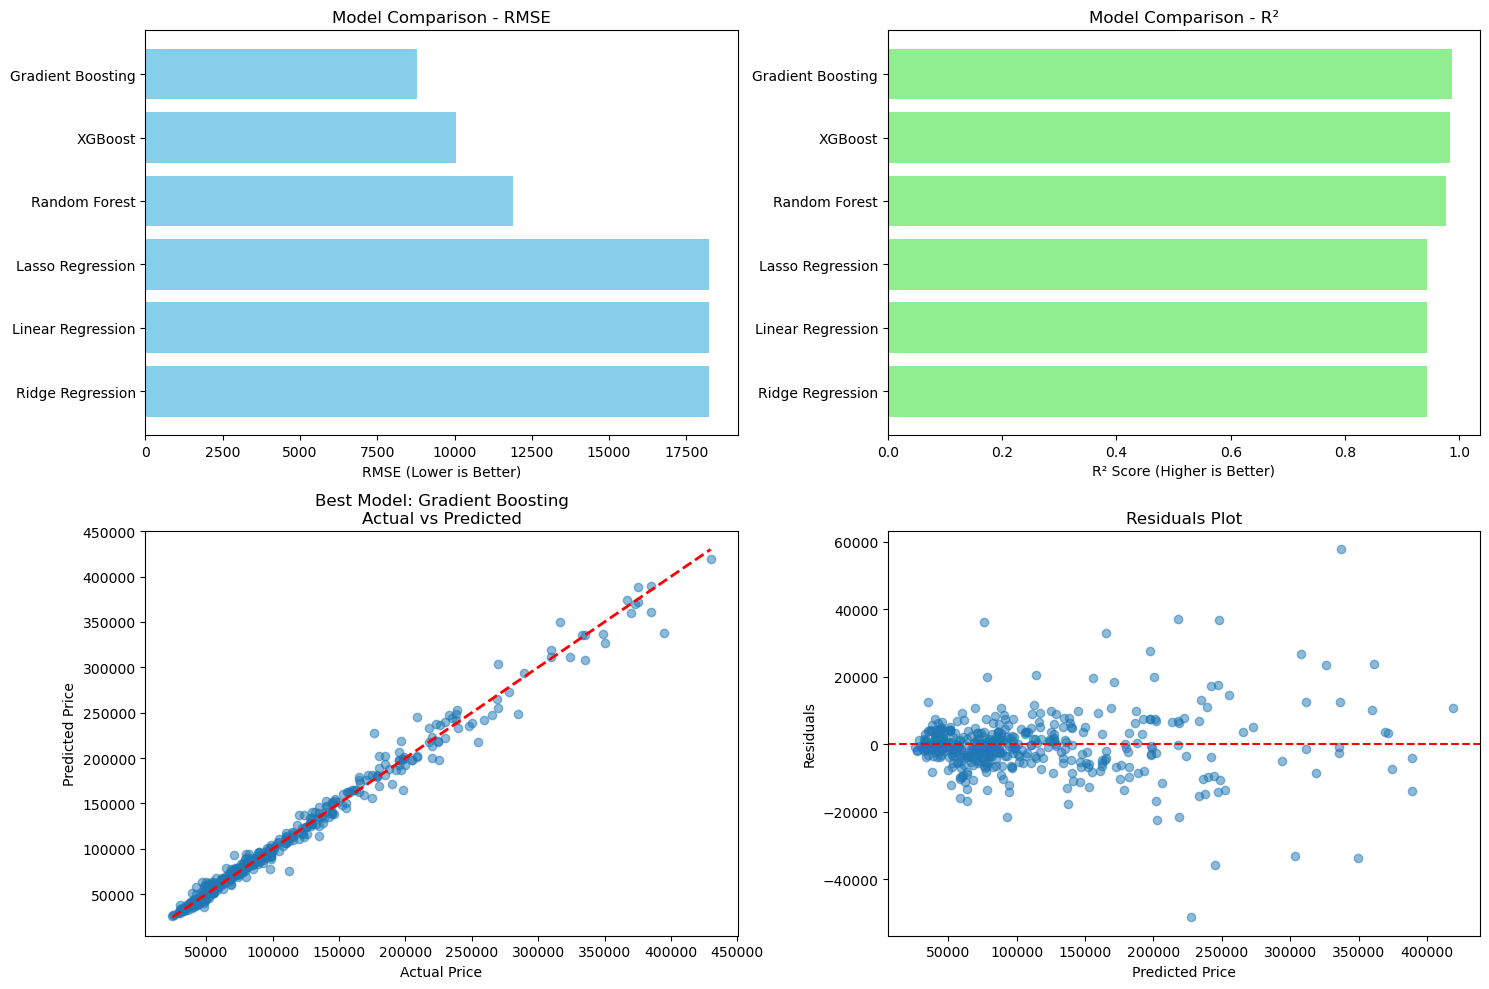


 FEATURE IMPORTANCE - Gradient Boosting
              feature  importance
11      model_encoded    0.650870
8    price_per_fiscal    0.206027
3   puissance_fiscale    0.106080
0         kilometrage    0.022590
6             car_age    0.008682
2        transmission    0.003721
7              is_new    0.000697
15       fuel_hybride    0.000677
13    fuel_electrique    0.000271
5               month    0.000168


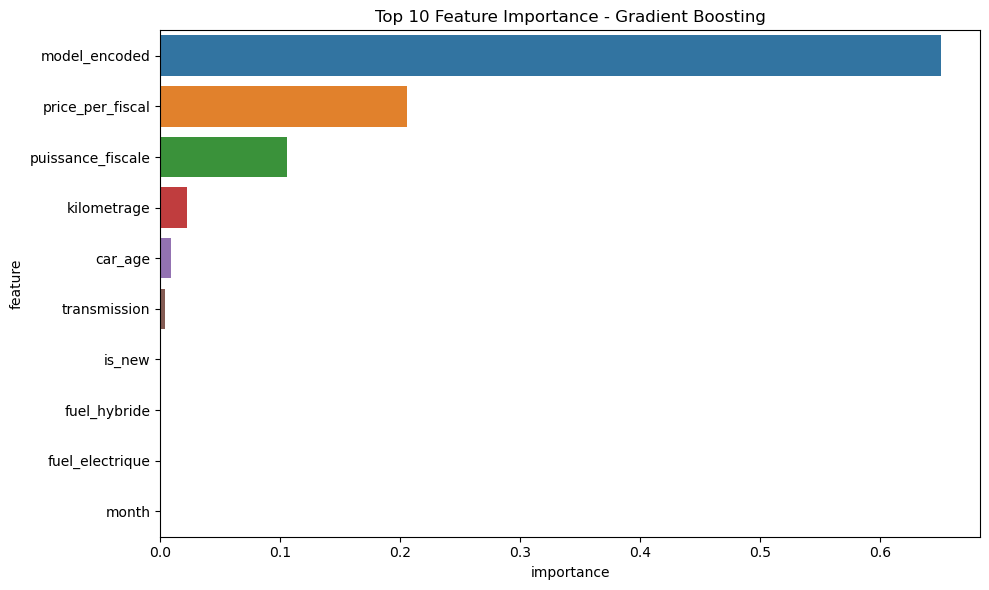


PREDICTION EXAMPLES - Gradient Boosting
Car 1: Actual = 73,000 TND, Predicted = 75,542 TND, Error = 3.5%
Car 2: Actual = 375,000 TND, Predicted = 371,552 TND, Error = 0.9%
Car 3: Actual = 125,000 TND, Predicted = 124,106 TND, Error = 0.7%
Car 4: Actual = 42,000 TND, Predicted = 49,662 TND, Error = 18.2%
Car 5: Actual = 75,000 TND, Predicted = 71,726 TND, Error = 4.4%
Car 6: Actual = 36,000 TND, Predicted = 33,105 TND, Error = 8.0%
Car 7: Actual = 78,000 TND, Predicted = 79,544 TND, Error = 2.0%
Car 8: Actual = 81,000 TND, Predicted = 81,987 TND, Error = 1.2%
Car 9: Actual = 98,000 TND, Predicted = 101,062 TND, Error = 3.1%
Car 10: Actual = 105,000 TND, Predicted = 97,575 TND, Error = 7.1%

 MODELING COMPLETED! Best model: Gradient Boosting


In [29]:
# =============================================================================
# CAR PRICE PREDICTION - MODELING PHASE (FIXED)
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. FINAL DATA CHECK AND CLEAN
# =============================================================================

print("🔍Final data check...")
print(f"Data types:\n{merged_clean.dtypes}")

# Check for any remaining non-numeric columns
non_numeric_cols = merged_clean.select_dtypes(include=['object']).columns
print(f"\nNon-numeric columns: {list(non_numeric_cols)}")

# If there are any non-numeric columns, convert them
for col in non_numeric_cols:
    print(f"Converting {col} to numeric...")
    merged_clean[col] = pd.to_numeric(merged_clean[col], errors='coerce')

# Drop any remaining NaN values
merged_clean = merged_clean.dropna()

print(f" Final clean dataset: {merged_clean.shape}")

# =============================================================================
# 2. PREPARE DATA FOR MODELING
# =============================================================================

# Separate features and target
X = merged_clean.drop('price', axis=1)
y = merged_clean['price']

# Ensure all features are numeric
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna(axis=1)  # Drop any columns that couldn't be converted

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(" Data split completed!")
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

# =============================================================================
# 3. SCALE FEATURES
# =============================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Feature scaling completed!")

# =============================================================================
# 4. INITIALIZE AND TRAIN MODELS
# =============================================================================

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

print("\n TRAINING MODELS...")
print("=" * 60)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    try:
        # Use scaled features for Linear, Ridge, Lasso
        if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            # Tree-based models don't need scaling
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        
        # Calculate metrics
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        # Store results
        results[name] = {
            'MAE': mae,
            'RMSE': rmse, 
            'R2': r2,
            'Predictions': y_pred,
            'Model': model
        }
        
        print(f"  MAE: {mae:,.0f} TND")
        print(f"  RMSE: {rmse:,.0f} TND") 
        print(f"  R²: {r2:.3f}")
        
    except Exception as e:
        print(f"  Error with {name}: {e}")

# =============================================================================
# 5. COMPARE MODEL PERFORMANCE
# =============================================================================

print("\n" + "=" * 60)
print(" MODEL COMPARISON")
print("=" * 60)

if results:
    # Create comparison DataFrame
    comparison_df = pd.DataFrame({
        'Model': list(results.keys()),
        'MAE': [results[name]['MAE'] for name in results.keys()],
        'RMSE': [results[name]['RMSE'] for name in results.keys()],
        'R²': [results[name]['R2'] for name in results.keys()]
    }).sort_values('RMSE')

    print(comparison_df.round(3))

    # =============================================================================
    # 6. VISUALIZE RESULTS
    # =============================================================================

    # Plot model performance
    plt.figure(figsize=(15, 10))

    # RMSE comparison
    plt.subplot(2, 2, 1)
    models_sorted = comparison_df['Model'].values
    rmse_sorted = comparison_df['RMSE'].values
    plt.barh(models_sorted, rmse_sorted, color='skyblue')
    plt.xlabel('RMSE (Lower is Better)')
    plt.title('Model Comparison - RMSE')
    plt.gca().invert_yaxis()

    # R² comparison
    plt.subplot(2, 2, 2)
    r2_sorted = comparison_df['R²'].values
    plt.barh(models_sorted, r2_sorted, color='lightgreen')
    plt.xlabel('R² Score (Higher is Better)')
    plt.title('Model Comparison - R²')
    plt.gca().invert_yaxis()

    # Actual vs Predicted for best model
    best_model_name = comparison_df.iloc[0]['Model']
    best_predictions = results[best_model_name]['Predictions']

    plt.subplot(2, 2, 3)
    plt.scatter(y_test, best_predictions, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title(f'Best Model: {best_model_name}\nActual vs Predicted')

    # Residuals plot
    plt.subplot(2, 2, 4)
    residuals = y_test - best_predictions
    plt.scatter(best_predictions, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Price')
    plt.ylabel('Residuals')
    plt.title('Residuals Plot')

    plt.tight_layout()
    plt.show()

    # =============================================================================
    # 7. FEATURE IMPORTANCE
    # =============================================================================

    print(f"\n FEATURE IMPORTANCE - {best_model_name}")
    print("=" * 60)

    best_model = results[best_model_name]['Model']
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': best_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print(feature_importance.head(10))
        
        # Plot feature importance
        plt.figure(figsize=(10, 6))
        sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
        plt.title(f'Top 10 Feature Importance - {best_model_name}')
        plt.tight_layout()
        plt.show()

    # =============================================================================
    # 8. PREDICTION EXAMPLES
    # =============================================================================

    print(f"\nPREDICTION EXAMPLES - {best_model_name}")
    print("=" * 60)

    # Show some actual predictions
    sample_indices = np.random.choice(len(y_test), 10, replace=False)
    for i, idx in enumerate(sample_indices):
        actual = y_test.iloc[idx]
        predicted = best_predictions[idx]
        error = abs(actual - predicted)
        error_pct = (error / actual) * 100
        
        print(f"Car {i+1}: Actual = {actual:,.0f} TND, "
              f"Predicted = {predicted:,.0f} TND, "
              f"Error = {error_pct:.1f}%")

    print(f"\n MODELING COMPLETED! Best model: {best_model_name}")
else:
    print(" No models were successfully trained!")